In [1]:
#Loads/Imports
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np
import pandas as pd
from sklearn import decomposition
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
import tqdm
import torch
import cv2
from cv2 import imwrite
from PIL import Image

In [2]:
#GPU

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
  # Make CuDNN Determinist
  torch.backends.cudnn.deterministic = True
  torch.cuda.manual_seed(seed)

# Define default device, we should use the GPU (cuda) if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

True


In [3]:
# Loading Images and Data
# Loop through all image files in the folder, all pngs, tiffs, and masks are all indexed to align

# Note, for the purposes of this problem, the images are all ordered in alphanumerical order, their timestamps are written such that ordering in this manner retains traceability to the steering angle and throttle

folder_path = "/home/exouser/HW3/Big_Dataset/IMG/"
files= os.listdir(folder_path) #OS is an operating system object, listdir is a file objkect
files=sorted(files) #sorts in alphabetical order
images=[] #Declare images as an empty object
rover_csv=[]


for filename in files:
    filename = folder_path + str(filename).strip()
    #print(filename)

    if filename.endswith((".csv")):  #look for png files
            if os.path.getsize(filename) == 0:
                 print(f"File '{filename}' is empty. Terminating Loop")
                 break
            else:
                rover_csv= pd.read_csv(filename, delimiter=r';',engine='python')
            continue

    if filename.endswith((".jpg")):  #look for jpg files
        img = mpimg.imread(filename)  # Read the image
        images.append(img)
        continue


print("Loaded", len(images), "images")


Loaded 16383 images


In [4]:
#Set Labels
SteerAngle =rover_csv['SteerAngle'].to_numpy()
Throttle = rover_csv['Throttle'].to_numpy()


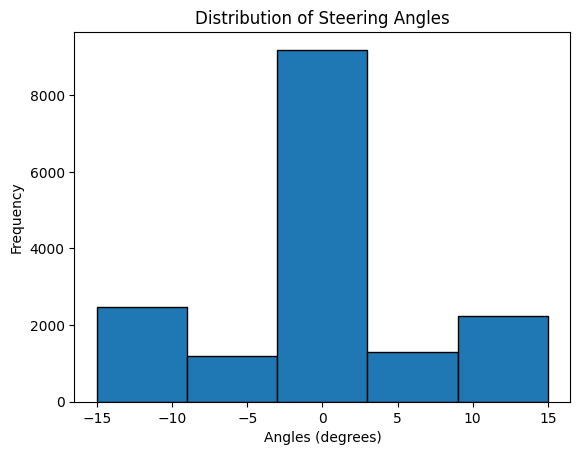

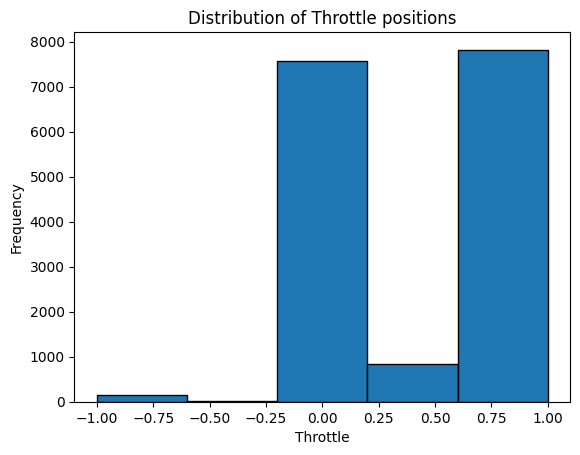

In [6]:
#Plot data distributions
rover_csv['SteerAngle'].hist(bins=5, edgecolor='black')
plt.title('Distribution of Steering Angles')
plt.xlabel('Angles (degrees)')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

rover_csv['Throttle'].hist(bins=5, edgecolor='black')
plt.title('Distribution of Throttle positions')
plt.xlabel('Throttle')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()



0       C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
1       C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
2       C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
3       C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
4       C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
                              ...                        
3529    C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
3530    C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
3531    C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
3532    C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
3533    C:\Mark's Python files\ME5920\HW3_Gardocki\IMG...
Name: Path, Length: 3534, dtype: object 0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
3529    0.0
3530    0.0
3531    0.0
3532    0.0
3533    0.0
Name: SteerAngle, Length: 3534, dtype: float64 0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
3529    0.0
3530    0.0
3531    0.0
3532    0.0
3533    0.0
Name: Throt

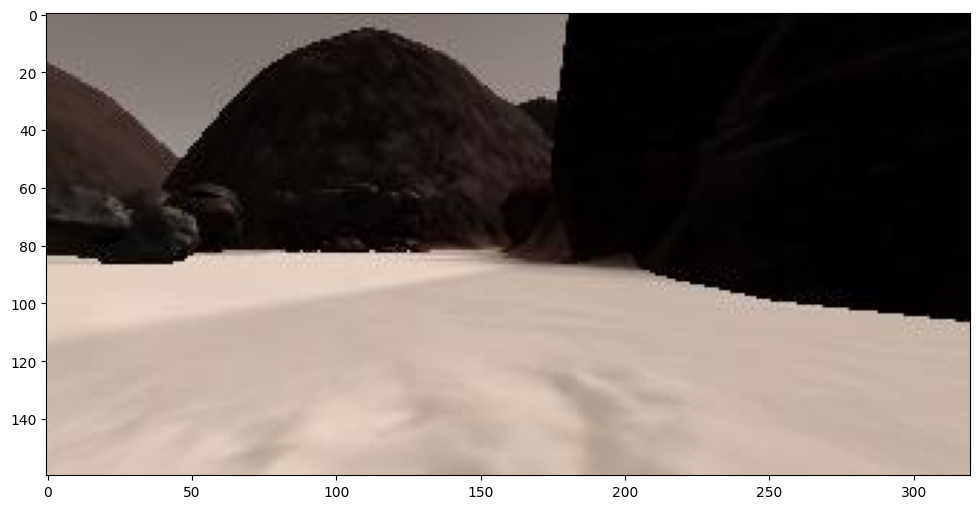

In [47]:
#Inspect
print(rover_csv['Path'],rover_csv['SteerAngle'],rover_csv['Throttle'])

print(images[len(images)-1].shape)
#Inspect Image Dataset
plt.figure(figsize=(12, 6))
plt.imshow(images[len(images)-1])

In [40]:

#Large Scale Test Dataloader, used for checking performance on group member data
X = images
X = np.array(X)
X=torch.tensor(X)
X=X.permute(0,3,1,2)
X=X.to(torch.float32)
print(X.shape)

y = torch.tensor(SteerAngle).to(torch.float32)  # 1000 target values for regression
z = torch.tensor(Throttle).to(torch.float32)  # 1000 target values for regression


X_train, X_test, y_train, y_test,z_train, z_test = train_test_split(X, y,z, test_size=0.99, random_state=42)

#Define special class for dataset with multiple targets
class MultiTargetDataset(Dataset):
    def __init__(self, X, y, z):
        self.X = X
        self.y = y
        self.z = z

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index], self.z[index]  # Returning 3 values

# Create dataset and DataLoader
train_dataset2 = MultiTargetDataset(X_train, y_train, z_train)
test_dataset2 = MultiTargetDataset(X_test, y_test, z_test)
train_loader2 = DataLoader(train_dataset2, batch_size=28, shuffle=False)
test_loader2 = DataLoader(test_dataset2, batch_size=28, shuffle=False)


torch.Size([3534, 3, 160, 320])


In [ ]:
X = images
X = np.array(X)
X=torch.tensor(X)
X=X.permute(0,3,1,2)
X=X.to(torch.float32)
print(X.shape)

y = torch.tensor(SteerAngle).to(torch.float32)  # 1000 target values for regression
z = torch.tensor(Throttle).to(torch.float32)  # 1000 target values for regression


X_train, X_test, y_train, y_test,z_train, z_test = train_test_split(X, y,z, test_size=0.25, random_state=42)

#Define special class for dataset with multiple targets
class MultiTargetDataset(Dataset):
    def __init__(self, X, y, z):
        self.X = X
        self.y = y
        self.z = z

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index], self.z[index]  # Returning 3 values

# Create dataset and DataLoader
train_dataset = MultiTargetDataset(X_train, y_train, z_train)
test_dataset = MultiTargetDataset(X_test, y_test, z_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [1]:
#Verify dataset sizes
print(X.size())
1000, 3, 64, 64
print(X.size())
print(y_train.shape)
print(z_train.shape)
print(y_test.shape)
print(z_test.shape)

NameError: name 'X' is not defined

In [17]:
# Define the CNN model for regression
class CNNRegressor(nn.Module):
    def __init__(self):
        super(CNNRegressor, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  # 3 input channels (RGB)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(32)
        self.bn2 = torch.nn.BatchNorm2d(64)
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 20 * 40, 128)  # This is designed to take in the flattened input, eg the convolutional outputs. The final output size is 64 Channels X 40 Height X 80 Wide.  These numbers will necessarily have to change if you add more pooling layers
        self.fc2 = nn.Linear(128, 2)  # Output a single continuous value, edited to two
        self.dp1 = torch.nn.Dropout(0.2)  


    def forward(self, x):
        # Convolutional layers with ReLU activation and MaxPooling
        x = torch.relu(self.conv1(x)) #Takes convolution output and only keeps positive numbers
        #x = self.bn1(x) #add batch norm layer
        x = torch.max_pool2d(x, 2) # pools input from relu using a 2X2 Window

        x = torch.relu(self.conv2(x))
        #x=  self.bn2(x)
        x = torch.max_pool2d(x, 2)

        x = torch.relu(self.conv3(x))
        #x=  self.bn2(x)
        x = torch.max_pool2d(x, 2)

    
                
        # Flatten the output from the convolutional layers to feed into fully connected layers
        x = x.view(x.size(0), -1) #I know what the dimensions of this output are, but what is it actually doing in terms of what it puts where?

        # Fully connected layers
        x = torch.relu(self.fc1(x))
        #x = self.dp1(x) #add dropout layer
        x = self.fc2(x)

        return x

In [18]:
# Initialize 
model_conv_chris= CNNRegressor().to(device)

# Loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model_conv_chris.parameters(), lr=0.001)

# Training loop
num_epochs = 40
for epoch in range(num_epochs):
    model_conv_chris.train()  # Set the model to training mode
    running_loss_y = 0.0
    running_loss_z = 0.0

    #for inputs, targets in train_loader:
    for inputs, y, z in train_loader:
        inputs, y, z = inputs.to(device) ,y.to(device) , z.to(device)
        optimizer.zero_grad()  # Clear gradients from previous step
         # Forward pass
        outputs = model_conv_chris(inputs)
        ####Interrogation lines
        #print(outputs.shape)
        #print(y.shape)
        #print(z.shape)
        #loss = criterion(outputs, targets)
        loss_y = criterion(outputs[:,0], y)
        loss_z = criterion(outputs[:,1], z)
        ####Interrogation lines
        #print(outputs.shape,epoch,"/n")
        #print(y.shape,epoch,"/n")
        #print(z.shape,epoch,"/n")
        #print(outputs[0],y[0],z[0],epoch,"/n")
        # Backward pass and optimization
        #loss.backward()
        loss_y.backward(retain_graph=True)
        loss_z.backward()
        optimizer.step()

        #running_loss += loss.item()
        running_loss_y += loss_y.item()
        running_loss_z += loss_z.item() #Break loss into two functions for Y and Z so you can plot them separately

    # Print the average loss for the epoch
    avg_train_loss_y = running_loss_y / len(train_loader) 
    avg_train_loss_z = running_loss_z / len(train_loader) 
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss y: {avg_train_loss_y:.4f}')
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss z: {avg_train_loss_z:.4f}')

# Evaluation on the test set
model_conv_chris.eval()  # Set to evaluation mode
with torch.no_grad():
    running_loss_y = 0.0
    running_loss_z = 0.0
    #for inputs, targets in train_loader:
    for inputs, y, z in test_loader:
        inputs, y, z = inputs.to(device) ,y.to(device) , z.to(device)
        outputs = model_conv_chris(inputs)
        #loss = criterion(outputs, targets)
        loss_y = criterion(outputs[:,0], y)
        loss_z = criterion(outputs[:,1], z)

        #running_loss += loss.item()
        running_loss_y += loss_y.item()
        running_loss_z += loss_z.item()

    avg_test_loss_y = running_loss_y / len(test_loader) 
    avg_test_loss_z = running_loss_z / len(test_loader) 
    print(f'Test Loss y: {avg_test_loss_y:.4f}')
    print(f'Test Loss z: {avg_test_loss_z:.4f}')

Epoch [1/40], Loss y: 799.4419
Epoch [1/40], Loss z: 3403.4399
Epoch [2/40], Loss y: 49.1810
Epoch [2/40], Loss z: 0.4699
Epoch [3/40], Loss y: 42.7281
Epoch [3/40], Loss z: 0.7363
Epoch [4/40], Loss y: 26.5172
Epoch [4/40], Loss z: 0.3674
Epoch [5/40], Loss y: 17.8465
Epoch [5/40], Loss z: 0.4336
Epoch [6/40], Loss y: 11.3222
Epoch [6/40], Loss z: 0.2386
Epoch [7/40], Loss y: 9.3035
Epoch [7/40], Loss z: 0.2661
Epoch [8/40], Loss y: 7.2478
Epoch [8/40], Loss z: 0.2544
Epoch [9/40], Loss y: 6.1092
Epoch [9/40], Loss z: 0.1628
Epoch [10/40], Loss y: 4.4839
Epoch [10/40], Loss z: 0.1495
Epoch [11/40], Loss y: 4.1887
Epoch [11/40], Loss z: 0.1404
Epoch [12/40], Loss y: 3.8696
Epoch [12/40], Loss z: 0.1269
Epoch [13/40], Loss y: 2.8506
Epoch [13/40], Loss z: 0.0969
Epoch [14/40], Loss y: 3.1153
Epoch [14/40], Loss z: 0.1062
Epoch [15/40], Loss y: 2.3464
Epoch [15/40], Loss z: 0.0838
Epoch [16/40], Loss y: 2.4699
Epoch [16/40], Loss z: 0.0929
Epoch [17/40], Loss y: 2.2802
Epoch [17/40], Los

In [53]:
#Save models and weights of desired model
torch.save(model_conv_chris.state_dict(), '/home/exouser/HW3/Models/model_conv_chris.pth')

In [55]:
#Load desired model
model_conv_chris = CNNRegressor()  #Note, this means that you will need to match the architecture of your saved models as well
model_conv_chris.load_state_dict(torch.load('/home/exouser/HW3/Models/model_conv_chris.pth'))

<All keys matched successfully>

In [19]:
import matplotlib as plt
from sklearn.metrics import mean_squared_error
# After training, evaluate on the test set
model_conv_chris.eval()  # Set to evaluation mode
with torch.no_grad():
    running_loss_y = 0.0
    running_loss_z = 0.0
    predictions_1 = []
    predictions_2 = []
    actuals_y = []
    actuals_z = []
    #for inputs, targets in train_loader:
    for inputs, y, z in test_loader: 
        inputs, y, z = inputs.to(device) ,y.to(device) , z.to(device)
        outputs = model_conv_chris(inputs)

        #loss = criterion(outputs, targets)
        loss_y = criterion(outputs[:,0], y)
        loss_z = criterion(outputs[:,1], z)

        #running_loss += loss.item()
        running_loss_y += loss_y.item()
        running_loss_z += loss_z.item()
        predictions_1.extend(outputs[:,0].squeeze().tolist())
        predictions_2.extend(outputs[:,1].squeeze().tolist())
        actuals_y.extend(y.squeeze().tolist())
        actuals_z.extend(z.squeeze().tolist())

    mse_y = mean_squared_error(actuals_y, predictions_1)
    mse_z = mean_squared_error(actuals_z, predictions_2)
    
    print(f'MSE y: {mse_y:.4f}')
    print(f'MSE z: {mse_z:.4f}')

    
#Note, this routine will fail if a batch of 1 is entered

MSE y: 8.7086
MSE z: 0.0887


In [41]:

#Large Scale Test Runner, used for evaluating group member datasets
import matplotlib as plt

# After training, evaluate on the test set
model_conv_chris.eval()  # Set to evaluation mode
with torch.no_grad():
    running_loss_y = 0.0
    running_loss_z = 0.0
    predictions_1 = []
    predictions_2 = []
    actuals_y = []
    actuals_z = []
    #for inputs, targets in train_loader:
    for inputs, y, z in test_loader2: 
        inputs, y, z = inputs.to(device) ,y.to(device) , z.to(device)
        outputs = model_conv_chris(inputs)
        
        #loss = criterion(outputs, targets)
        loss_y = criterion(outputs[:,0], y)
        loss_z = criterion(outputs[:,1], z)

        #running_loss += loss.item()
        running_loss_y += loss_y.item()
        running_loss_z += loss_z.item()
        predictions_1.extend(outputs[:,0].squeeze().tolist())
        predictions_2.extend(outputs[:,1].squeeze().tolist())
        actuals_y.extend(y.squeeze().tolist())
        actuals_z.extend(z.squeeze().tolist())

    mse_y = mean_squared_error(actuals_y, predictions_1)
    mse_z = mean_squared_error(actuals_z, predictions_2)
    
    print(f'MSE y: {mse_y:.4f}')
    print(f'MSE z: {mse_z:.4f}')
    
#Note, this routine will fail if a batch of 1 is entered


MSE y: 71.7064
MSE z: 0.3271


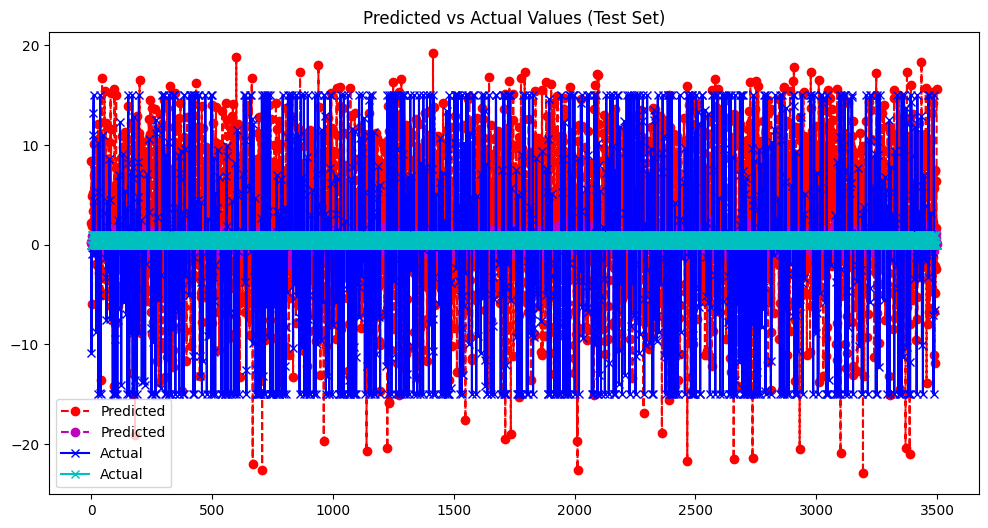

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(predictions_1[:], label='Predicted', marker='o', linestyle='--', color='r')
plt.plot(predictions_2[:], label='Predicted', marker='o', linestyle='--', color='m')
plt.plot(actuals_y[:], label='Actual', marker='x', linestyle='-', color='b')
plt.plot(actuals_z[:], label='Actual', marker='x', linestyle='-', color='c')
plt.legend()
plt.title('Predicted vs Actual Values (Test Set)')
plt.show()